# NYC Building Energy & Emissions Data Analysis
**Dataset:** NYC Building Energy and Water Data Disclosure (Local Law 84) — 2022 to Present (this version shows a reduced df down to ~2k rows due to small upload file size) 
**Author:** Katelyn Louie, Tasnia Ahmed
**Course:** CS 101 — Survey of CS in Python 

---

## Overview
This notebook explores NYC building energy and emissions data using Python (pandas, matplotlib, seaborn).  
The dataset contains over 100,000 property records across all five boroughs, reported under NYC Local Law 84 —
a mandate requiring large buildings to track and disclose their energy and water usage.

Three core questions are investigated:
1. **Where are GHG emissions concentrated across NYC?** *(Geospatial heatmap)*
2. **How do ENERGY STAR Scores vary by building type?** *(Distribution analysis)*
3. **How is site energy use intensity (EUI) distributed across NYC buildings in 2022?** *(Distribution analysis)*

---

## Setup
Load the dataset and import core libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')

csv_path = 'reduced_df.csv'
df = pd.read_csv(csv_path, engine='python')
print(f'Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')

Matplotlib is building the font cache; this may take a moment.


Dataset loaded: 1,840 rows, 265 columns


---
## Question 1: Where Are GHG Emissions Concentrated Across NYC?

**Column used:** `Total (Location-Based) GHG Emissions Intensity (kgCO2e/ft²)`

This metric measures how much greenhouse gas a building emits per square foot — a standard benchmark
in sustainable architecture and urban planning. Mapping it geographically reveals which neighborhoods
have the highest-emitting buildings, directly relevant to architectural and infrastructure decision-making.

**Data cleaning steps:**
- Selected only GHG intensity, latitude, and longitude columns
- Dropped rows with missing values
- Converted GHG values to numeric, removing invalid entries
- Filtered to positive GHG intensity values only (zeros/negatives are likely data errors)

In [2]:
# Select relevant columns and drop missing values
col_ghg = 'Total (Location-Based) GHG Emissions Intensity (kgCO2e/ft²)'
df_q1 = df[[col_ghg, 'Longitude', 'Latitude']].dropna()

# Convert GHG intensity to numeric
df_q1[col_ghg] = pd.to_numeric(df_q1[col_ghg], errors='coerce')
df_q1 = df_q1.dropna()

# Keep only positive GHG values
df_pos = df_q1[df_q1[col_ghg] > 0]
print(f'Records used for heatmap: {len(df_pos):,}')

Records used for heatmap: 1,721


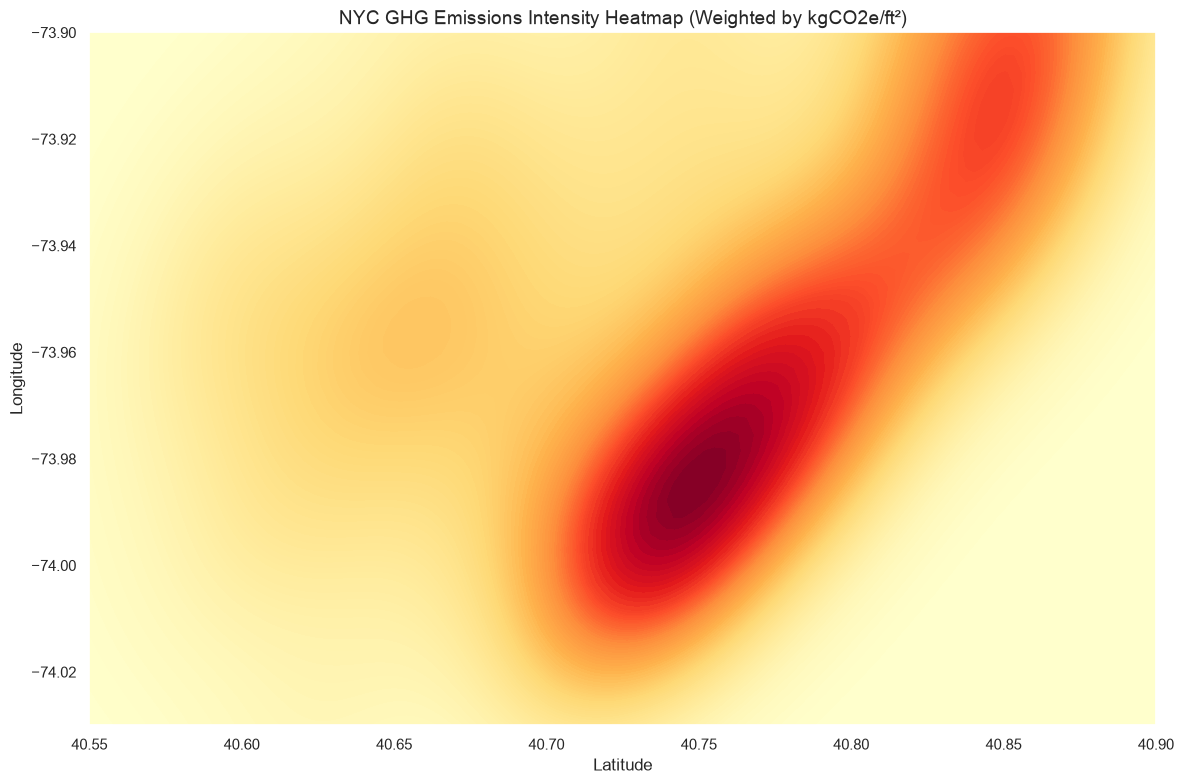

In [3]:
col_ghg = 'Total (Location-Based) GHG Emissions Intensity (kgCO2e/ft²)'

plt.figure(figsize=(12, 8))

sns.kdeplot(
    x=df_pos['Latitude'],
    y=df_pos['Longitude'],
    weights=df_pos[col_ghg],
    cmap='YlOrRd',
    fill=True,
    thresh=0,
    levels=100
)

plt.title('NYC GHG Emissions Intensity Heatmap (Weighted by kgCO2e/ft²)', fontsize=14)
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.xlim(40.55, 40.9)
plt.ylim(-74.03, -73.90)
plt.tight_layout()
plt.show()

### Findings
* **Density & Building Scale:** The intensity gradient follows major commercial and residential development patterns, extending northeast into upper Manhattan and the Bronx while tapering off in lower-density outer regions.
* **Policy Application:** Mapping emissions intensity highlights specific spatial zones where building decarbonization mandates, energy efficiency incentives, and green infrastructure upgrades will yield the highest return on investment for reducing overall NYC emissions.

---
## Question 2: How Do ENERGY STAR Scores Differ Across Building Types?

**Columns used:** `Primary Property Type - Portfolio Manager-Calculated`, `ENERGY STAR Score`

ENERGY STAR Scores range from 1–100, where 75+ qualifies a building for certification. Understanding score
distributions by building type helps identify which property categories tend to be more or less energy efficient
— directly useful for architecture and facility management teams.

**Data cleaning steps:**
- Selected property type and ENERGY STAR score columns, dropped nulls
- Converted scores to numeric, removed remaining nulls after coercion
- Filtered to the top 10 most common building types for a readable visualization

In [4]:
col_type = 'Primary Property Type - Portfolio Manager-Calculated'

df_energy = df[[col_type, 'ENERGY STAR Score']].dropna()
df_energy['ENERGY STAR Score'] = pd.to_numeric(df_energy['ENERGY STAR Score'], errors='coerce')
df_energy = df_energy.dropna()

# Limit to top 10 building types for readability
top_types = df_energy[col_type].value_counts().head(10).index
df_energy_top = df_energy[df_energy[col_type].isin(top_types)]

print(f'Building types shown: {df_energy_top[col_type].nunique()}')
print(f'Records used: {len(df_energy_top):,}')

Building types shown: 10
Records used: 1,493


/var/folders/rq/9vb5sgxj67125rjfhtyc3lnc0000gn/T/ipykernel_18734/3140261307.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


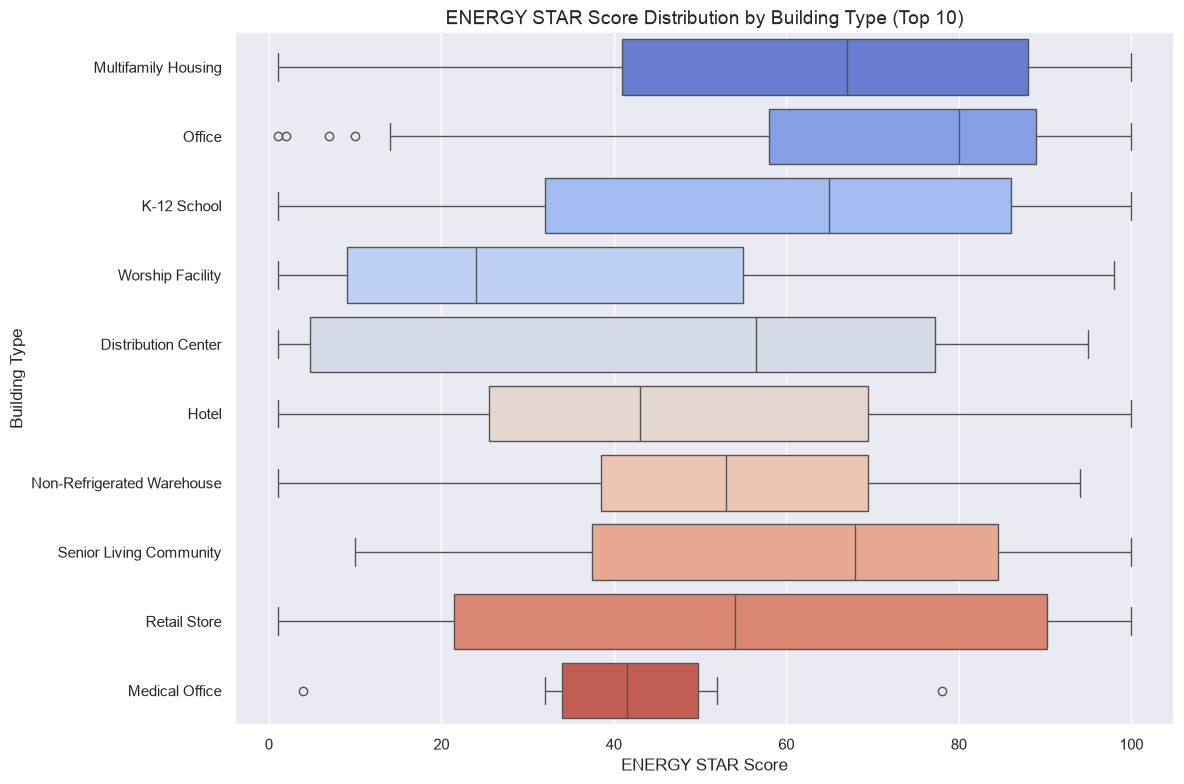

In [5]:
col_type = 'Primary Property Type - Portfolio Manager-Calculated'

plt.figure(figsize=(12, 8))

sns.boxplot(
    x='ENERGY STAR Score',
    y=col_type,
    data=df_energy_top,
    palette='coolwarm'
)

plt.title('ENERGY STAR Score Distribution by Building Type (Top 10)', fontsize=14)
plt.xlabel('ENERGY STAR Score')
plt.ylabel('Building Type')
plt.tight_layout()
plt.show()

### Findings
* Office buildings consistently score highest in ENERGY STAR performance across the primary property types, frequently reaching top-performer status (>75).
* **Performance Disparities:** Multifamily Housing and K-12 Schools exhibit lower median scores and wider overall spreads, reflecting varying building age, infrastructure limits, and resource availability.
* **Compliance & Impact:** Under NYC Local Law 84, identifying these performance clusters helps pin-point building sectors (such as schools and residential properties) that need targeted energy-efficiency investments to lower citywide emissions.

---
## Question 3: How Has Energy Use Intensity Changed Year Over Year?

**Columns used:** `Calendar Year`, `Site EUI (kBtu/ft²)`, `Property GFA - Self-Reported (ft²)`

Site Energy Use Intensity (EUI) measures total energy consumed per square foot of building space.
Tracking this over time reveals whether NYC buildings are becoming more energy-efficient
— an important trend for sustainability-focused architecture and city planning.

**Data cleaning steps:**
- Filtered dataset to 2022 reporting year
- Converted Site EUI to numeric; setting invalid entries to null
- Replaced missing Site EUUI values with median (imputation)
- Filtered out extreme EUI outliers (above 95th percentile)

In [8]:
df_year = df[['Calendar Year', 'Site EUI (kBtu/ft²)', 'Property GFA - Self-Reported (ft²)']].copy()

# Clean calendar year
df_year['Calendar Year'] = pd.to_numeric(df_year['Calendar Year'], errors='coerce')

# Convert Site EUI; fill missing values with median (imputation)
df_year['Site EUI (kBtu/ft²)'] = pd.to_numeric(df_year['Site EUI (kBtu/ft²)'], errors='coerce')
median_eui = df_year['Site EUI (kBtu/ft²)'].median()
df_year['Site EUI (kBtu/ft²)'] = df_year['Site EUI (kBtu/ft²)'].fillna(median_eui)

unique_years = df_year['Calendar Year'].dropna().unique()
print(f'Years in dataset: {sorted(df_year["Calendar Year"].unique().tolist())}')
print(f'Records used: {len(df_year):,}')

Years in dataset: [2022]
Records used: 1,840


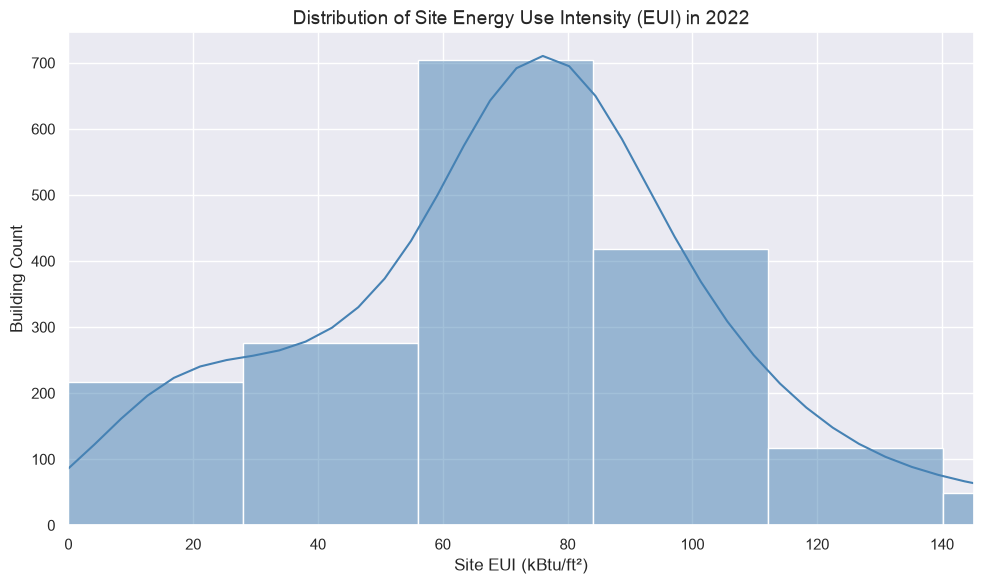

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_year,
    x='Site EUI (kBtu/ft²)',
    bins=30,
    kde=True,
    color='steelblue'
)

plt.title('Distribution of Site Energy Use Intensity (EUI) in 2022', fontsize=14)
plt.xlabel('Site EUI (kBtu/ft²)')
plt.ylabel('Building Count')
plt.xlim(0, df_year['Site EUI (kBtu/ft²)'].quantile(0.95)) 
plt.tight_layout()
plt.show()

### Findings
* **Distribution Shape:** The EUI distribution is right-skewed, showing that while most buildings cluster around moderate energy consumption levels, a subset of properties exhibits significantly higher energy intensity.
* **Urban Planning Insight:** Buildings situated on the higher end of the EUI spectrum represent prime targets for energy efficiency retrofits and electrification efforts to align with local emissions targets (e.g., Local Law 97).

---
## Summary & Key Takeaways

| Question | Visualization | Approach |
|---|---|---|
| GHG emissions geography | KDE Heatmap | Weighted by emissions intensity per ft² |
| ENERGY STAR by building type | Boxplot | Top 10 building types, score 1–100 |
| Energy use over time | Histogram | Distribution of Site Energy Use in 2022|

**Technical skills demonstrated:** pandas data cleaning, null handling, median imputation,
seaborn/matplotlib visualization, geospatial density plotting.

**Dataset source:** [NYC Open Data — Local Law 84 Energy Disclosure](https://data.cityofnewyork.us/)